<a href="https://colab.research.google.com/github/ac5589/Pytorch-tutorial-Youtube/blob/main/Pytorch_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [4]:
x = torch.empty(1, 2)
x

tensor([[[[2.6066e+04, 0.0000e+00],
          [0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00],
          [1.3593e-43, 0.0000e+00]]]])

In [14]:
x = torch.rand(2, 2, dtype=torch.float)
print(x)
print(x.mean(dim=1).view(2, -1))
print(x.dtype)
print(x.size())

tensor([[0.4510, 0.4989],
        [0.2439, 0.7137]])
tensor([[0.4749],
        [0.4788]])
torch.float32
torch.Size([2, 2])


In [24]:
x = torch.tensor([2, 5])
y = torch.tensor([7, 10])
print(f'x = {x}')
print(f'y = {y}')
print(x.dtype)
print((x + y).view(2, 1))
print(y.add_(x))
print(f'y = {y.view(2, 1)}')
print(f'y = {x/y}')

x = tensor([2, 5])
y = tensor([ 7, 10])
torch.int64
tensor([[ 9],
        [15]])
tensor([ 9, 15])
y = tensor([[ 9],
        [15]])
y = tensor([0.2222, 0.3333])


In [35]:
# Using the auto grad package

# Create an grad variable
x = torch.rand(1, requires_grad=True)
print(f'x = {x}')

# Perform an add operation [This is the forward pass]
y = x + 2
z = y * y * 2

# Calculate the gradient of z with respect to x
z.backward()

# The Gradient is stroed in the attribute of x called x.grad
# Here x.gad evalaute dz/dx at x
# Here dz/dx = 4*x + 8
print(f'dz/dx = 4x + 8 = {4*x + 8}')
print(f'x.grad = {x.grad}')

x = tensor([0.1343], requires_grad=True)
dz/dx = 4x + 8 = tensor([8.5372], grad_fn=<AddBackward0>)
x.grad = tensor([8.5372])


In [ ]:
# How to prevent pytorch to avoid gradient

#There are three methods to prevent tracking gradinet

# Option 1
# x.requires_grad_(False)

# Option 2
#x.detach()

# Option 3
#with torch.no_grad():


In [41]:
# GRadients should be zeros within the training loop
weight = torch.ones(4, requires_grad=True)

for epoch in range(4):
  model_output = (weight *3).sum()

  # Calculate the gradient
  model_output.backward()

  print(f'Weight grad = {weight.grad}')

  #without this step gradients will accumulate
  weight.grad.zero_()



Weight grad = tensor([3., 3., 3., 3.])
Weight grad = tensor([3., 3., 3., 3.])
Weight grad = tensor([3., 3., 3., 3.])
Weight grad = tensor([3., 3., 3., 3.])


In [44]:
# Back propagation algorithm

# Create a tensor

x = torch.tensor(1.0)

y = torch.tensor(2.0)

w = torch.tensor(1.0, requires_grad=True)

# forward passs
y_hat = w*x

loss = (y_hat - y)**2

print(loss)

# Backward pass
loss.backward()

print(w.grad)


tensor(1., grad_fn=<PowBackward0>)
tensor(-2.)


In [56]:
# Manual training

import numpy as np

# Linear regression f = w * x

X = np.array([1, 2, 3, 4], dtype=np.float32)

Y = np.array([2, 4, 6, 8], dtype = np.float32)

w = 0.0

# Model prediction

def forward(x):
  return w*x

def loss(y, y_predicted):
  return ((y_predicted -y)**2).mean()

def gradient(x, y, y_predicted):
  return np.dot(2*x, y_predicted-y).mean()

print(f'Prediction before training: f(5) = {forward(5)}')

# Training

learning_rate = 0.01
n_iters = 20

for epoch in range(n_iters):
  y_pred = forward(X)

  l = loss(Y, y_pred)

  dw = gradient(X, Y, y_pred)

  w -= learning_rate * dw

  if epoch%1==0:
    print(f'epoch = {epoch+1}: w = {w:.3f}, loss = {l:.8f}')

print(f'Prediction after training: f(5) = {forward(5)}')





Prediction before training: f(5) = 0.0
epoch = 1: w = 1.200, loss = 30.00000000
epoch = 2: w = 1.680, loss = 4.80000067
epoch = 3: w = 1.872, loss = 0.76800019
epoch = 4: w = 1.949, loss = 0.12288000
epoch = 5: w = 1.980, loss = 0.01966083
epoch = 6: w = 1.992, loss = 0.00314574
epoch = 7: w = 1.997, loss = 0.00050332
epoch = 8: w = 1.999, loss = 0.00008053
epoch = 9: w = 1.999, loss = 0.00001288
epoch = 10: w = 2.000, loss = 0.00000206
epoch = 11: w = 2.000, loss = 0.00000033
epoch = 12: w = 2.000, loss = 0.00000005
epoch = 13: w = 2.000, loss = 0.00000001
epoch = 14: w = 2.000, loss = 0.00000000
epoch = 15: w = 2.000, loss = 0.00000000
epoch = 16: w = 2.000, loss = 0.00000000
epoch = 17: w = 2.000, loss = 0.00000000
epoch = 18: w = 2.000, loss = 0.00000000
epoch = 19: w = 2.000, loss = 0.00000000
epoch = 20: w = 2.000, loss = 0.00000000
Prediction after training: f(5) = 10.0


In [64]:
# Manual training
# Use gradient functon from pytorch

#import numpy as np

# Linear regression f = w * x

#X = np.array([1, 2, 3, 4], dtype=np.float32)
X = torch.tensor([1, 2, 3, 4], dtype=torch.float32)

#Y = np.array([2, 4, 6, 8], dtype = np.float32)
Y = torch.tensor([2, 4, 6, 8], dtype=torch.float32)

#w = 0.0
w = torch.tensor([0], dtype=torch.float32, requires_grad=True)

# Model prediction

def forward(x):
  return w*x

def loss(y, y_predicted):
  return ((y_predicted -y)**2).mean()

print(f'Prediction before training: f(5) = {forward(5)}')

# Training

learning_rate = 0.01
n_iters = 100

for epoch in range(n_iters):
  y_pred = forward(X)

  l = loss(Y, y_pred)

  #dw = gradient(X, Y, y_pred)
  l.backward()

  with torch.no_grad():
    #w -= learning_rate * dw
    w -= learning_rate * w.grad

  w.grad.zero_()

  if epoch%10==0:
    print(f'epoch = {epoch+1}: w = {w.item():.3f}, loss = {l.item():.8f}')

print(f'Prediction after training: f(5) = {forward(5)}')

Prediction before training: f(5) = tensor([0.], grad_fn=<MulBackward0>)
epoch = 1: w = 0.300, loss = 30.00000000
epoch = 11: w = 1.665, loss = 1.16278565
epoch = 21: w = 1.934, loss = 0.04506890
epoch = 31: w = 1.987, loss = 0.00174685
epoch = 41: w = 1.997, loss = 0.00006770
epoch = 51: w = 1.999, loss = 0.00000262
epoch = 61: w = 2.000, loss = 0.00000010
epoch = 71: w = 2.000, loss = 0.00000000
epoch = 81: w = 2.000, loss = 0.00000000
epoch = 91: w = 2.000, loss = 0.00000000
Prediction after training: f(5) = tensor([10.0000], grad_fn=<MulBackward0>)


In [83]:
#Complete operation using pytorch package

import torch.nn as nn

# Linear regression f = w * x

X = torch.tensor([[1], [2], [3], [4]], dtype=torch.float32)
Y = torch.tensor([[2], [4], [6], [8]], dtype=torch.float32)
X_test = torch.tensor([[5]], dtype=torch.float32)
n_sample, n_features = X.shape
print(n_sample, n_features)

input_size  = n_features
output_size = n_features

class LinearRegression(nn.Module):
  def __init__(self, input_dim, ouput_dim):
    super().__init__()
    self.lin = nn.Linear(in_features=input_size, out_features=output_size)

  def forward(self, x):
    return(self.lin(x))

model = LinearRegression(input_size, output_size)

print(f'Prediction before training: f(5) = {model(X_test).item()}')

# Training

learning_rate = 0.01
n_iters = 500

loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate)

for epoch in range(n_iters):
  y_pred = model(X)

  l = loss(Y, y_pred)

  #dw = gradient(X, Y, y_pred)
  l.backward()

  optimizer.step()

  optimizer.zero_grad()

  if epoch%100==0:
    [w, b] = model.parameters()
    print(f'epoch = {epoch+1}: w = {w[0][0].item():.3f}, loss = {l.item():.8f}')

print(f'Prediction after training: f(5) = {model(X_test).item()}')


4 1
Prediction before training: f(5) = 5.197327136993408
epoch = 1: w = 1.009, loss = 6.54298496
epoch = 101: w = 1.659, loss = 0.14810073
epoch = 201: w = 1.736, loss = 0.09616296
epoch = 301: w = 1.779, loss = 0.06702375
epoch = 401: w = 1.823, loss = 0.04319249
Prediction after training: f(5) = 9.704158782958984


epoch = 0: loss = 5672.5688
epoch = 10: loss = 4201.2314
epoch = 20: loss = 3138.0227
epoch = 30: loss = 2368.8428
epoch = 40: loss = 1811.7781
epoch = 50: loss = 1407.9319
epoch = 60: loss = 1114.8916
epoch = 70: loss = 902.0736
epoch = 80: loss = 747.3948
epoch = 90: loss = 634.8909


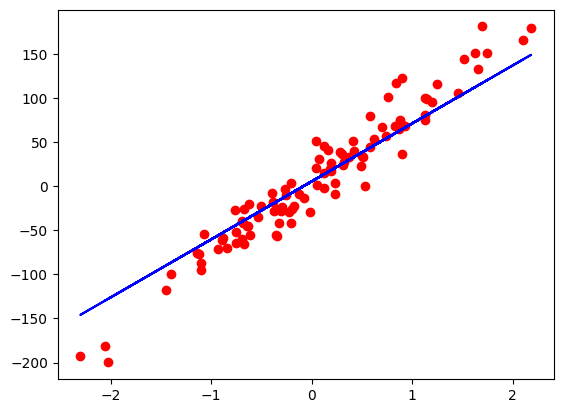

In [9]:
# Implement linear regression
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

# Data preparation

X_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)

X = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))
y = y.view(y.shape[0], 1)

n_samples, n_features = X.shape

input_size = n_features
output_size = 1

model = nn.Linear(in_features=input_size, out_features=output_size)

learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(100):

  # forward pass
  y_predicted = model(X)

  # compute loss
  loss = criterion(y_predicted, y)

  # backward pass
  loss.backward()

  # update the weights
  optimizer.step()

  # Make the gradinet zero
  # Empty the gradients
  optimizer.zero_grad()

  if epoch%10 ==0:
    print(f'epoch = {epoch}: loss = {loss.item():.4f}')

# plot the results
predicted = model(X).detach().numpy()

plt.plot(X, y, 'or')
plt.plot(X, predicted, 'b')


In [24]:
# Implement the logistic regressison

import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Data preparation
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

num_sample, num_features = X.shape

print(f'num_samples = {num_sample}, num_features = {num_features}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Scale the features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

# Reshape the vectors
y_train = y_train.view(y_train.shape[0], 1)
y_test = y_test.view(y_test.shape[0], 1)

# Layers
class LogisticRegression(nn.Module):
  def __init__(self, n_input_features, n_output_features):
    super().__init__() # instantiate our nn.module
    self.linear = nn.Linear(in_features=n_input_features, out_features=n_output_features)

  def forward(self, X):
    return torch.sigmoid(self.linear(X))

# Create the model
learning_rate = 0.01
Epochs = 500
model = LogisticRegression(num_features, 1)

loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

for epoch in range(Epochs):

  # Forward pass
  y_predicted = model(X_train)

  # Loss calculation
  Loss = loss_fn(y_predicted, y_train)

  # Backward pass
  Loss.backward()

  # Update the weights
  optimizer.step()

  # Empty the gradients
  optimizer.zero_grad()

  if epoch%10==0:
    print(f'Epoch = {epoch}: Loss = {Loss.item():.4f}')

with torch.no_grad():
  y_predicted = model(X_test)
  y_predicted_cls = y_predicted.round()
  acc = y_predicted_cls.eq(y_test).sum()/float(y_test.shape[0]) * 100
  print(f'Accuracy = {acc:.4f}')

num_samples = 569, num_features = 30
Epoch = 0: Loss = 0.8122
Epoch = 10: Loss = 0.6297
Epoch = 20: Loss = 0.5204
Epoch = 30: Loss = 0.4492
Epoch = 40: Loss = 0.3991
Epoch = 50: Loss = 0.3618
Epoch = 60: Loss = 0.3328
Epoch = 70: Loss = 0.3096
Epoch = 80: Loss = 0.2904
Epoch = 90: Loss = 0.2742
Epoch = 100: Loss = 0.2604
Epoch = 110: Loss = 0.2484
Epoch = 120: Loss = 0.2379
Epoch = 130: Loss = 0.2286
Epoch = 140: Loss = 0.2202
Epoch = 150: Loss = 0.2127
Epoch = 160: Loss = 0.2059
Epoch = 170: Loss = 0.1997
Epoch = 180: Loss = 0.1941
Epoch = 190: Loss = 0.1889
Epoch = 200: Loss = 0.1840
Epoch = 210: Loss = 0.1796
Epoch = 220: Loss = 0.1755
Epoch = 230: Loss = 0.1716
Epoch = 240: Loss = 0.1680
Epoch = 250: Loss = 0.1646
Epoch = 260: Loss = 0.1615
Epoch = 270: Loss = 0.1585
Epoch = 280: Loss = 0.1557
Epoch = 290: Loss = 0.1530
Epoch = 300: Loss = 0.1505
Epoch = 310: Loss = 0.1481
Epoch = 320: Loss = 0.1459
Epoch = 330: Loss = 0.1438
Epoch = 340: Loss = 0.1417
Epoch = 350: Loss = 0.1398
Ep

In [16]:
# How to use batch size

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math

class WineDataset(Dataset):
  def __init__(self):
    # data loading
    from google.colab import files
    uploaded = files.upload()
    xy = np.loadtxt('wine.csv', delimiter=',', dtype=np.float32, skiprows=1)
    self.x = torch.from_numpy(xy[:, 1:])
    self.y = torch.from_numpy(xy[:, 0])
    self.n_samples = xy.shape[0]

  def __getitem__(self, index):
    # dataset[0]
    return self.x[index], self.y[index]

  def __len__(self):
    # Length of the dataset
    return self.n_samples

dataset = WineDataset()
dataloader = DataLoader(dataset=dataset, batch_size=4, shuffle=True, num_workers=2)

# Hyper parameters
num_epoch = 2
total_samples = len(dataset)
n_iterations = math.ceil(total_samples/4)
print(f'total_samples = {total_samples}, n_iterations = {n_iterations}')

# training loop
for epoch in range(num_epoch):
  for i, (inputs, labels) in enumerate(dataloader):
    # forward pass
    if (i+1)%5 == 0:
      print(f'epoch = {epoch+1}/{num_epoch}, step{i+1}/{n_iterations}, input = {inputs.shape}')

Saving wine.csv to wine (12).csv
total_samples = 178, n_iterations = 45
epoch = 1/2, step5/45, input = torch.Size([4, 13])
epoch = 1/2, step10/45, input = torch.Size([4, 13])
epoch = 1/2, step15/45, input = torch.Size([4, 13])
epoch = 1/2, step20/45, input = torch.Size([4, 13])
epoch = 1/2, step25/45, input = torch.Size([4, 13])
epoch = 1/2, step30/45, input = torch.Size([4, 13])
epoch = 1/2, step35/45, input = torch.Size([4, 13])
epoch = 1/2, step40/45, input = torch.Size([4, 13])
epoch = 1/2, step45/45, input = torch.Size([2, 13])
epoch = 2/2, step5/45, input = torch.Size([4, 13])
epoch = 2/2, step10/45, input = torch.Size([4, 13])
epoch = 2/2, step15/45, input = torch.Size([4, 13])
epoch = 2/2, step20/45, input = torch.Size([4, 13])
epoch = 2/2, step25/45, input = torch.Size([4, 13])
epoch = 2/2, step30/45, input = torch.Size([4, 13])
epoch = 2/2, step35/45, input = torch.Size([4, 13])
epoch = 2/2, step40/45, input = torch.Size([4, 13])
epoch = 2/2, step45/45, input = torch.Size([2,

In [24]:
# How to use transform the data

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math

class WineDataset(Dataset):
  def __init__(self, transform=None):
    # data loading
    from google.colab import files
    uploaded = files.upload()
    xy = np.loadtxt('wine.csv', delimiter=',', dtype=np.float32, skiprows=1)
    self.x = xy[:, 1:]
    self.y = xy[:, [0]]
    self.n_samples = xy.shape[0]
    self.transform = transform

  def __getitem__(self, index):
    # dataset[0]
    sample = self.x[index], self.y[index]
    if self.transform:
      sample = self.transform(sample)
    return sample

  def __len__(self):
    # Length of the dataset
    return self.n_samples

class toTensor:
  def __call__(self, sample):
    inputs, targets = sample
    return torch.from_numpy(inputs), torch.from_numpy(targets)

class MulTransform:
  def __init__(self, factor):
    self.factor = factor

  def __call__(self, sample):
    inputs, targets = sample
    inputs *= self.factor
    return inputs, targets

dataset = WineDataset(transform=None)

first_data = dataset[0]
features, labels = first_data
print(features)
print(type(features), type(labels))

composed = torchvision.transforms.Compose([toTensor(), MulTransform(2)])
dataset = WineDataset(transform=composed)
first_data = dataset[0]
features, labels = first_data
print(features)
print(type(features), type(labels))

Saving wine.csv to wine (20).csv
[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


Saving wine.csv to wine (21).csv
tensor([2.8460e+01, 3.4200e+00, 4.8600e+00, 3.1200e+01, 2.5400e+02, 5.6000e+00,
        6.1200e+00, 5.6000e-01, 4.5800e+00, 1.1280e+01, 2.0800e+00, 7.8400e+00,
        2.1300e+03])
<class 'torch.Tensor'> <class 'torch.Tensor'>


In [29]:
# How to use softmax Layer

# Standard softmax layer

import numpy as np
import torch

# Implment softmax mathematically
def softmax(x):
  return np.exp(x)/np.sum(np.exp(x), axis=0)
x = np.array([2.0, 1.0, 0.1])

outputs = softmax(x)

print(f'Softmax from numpy: {outputs}')
print(f'Sum of softmax from numpy: {outputs.sum()}')

x = torch.tensor([2.0, 1.0, 0.1])
outputs = torch.softmax(x, dim=0)
print(f'Softmax torch: {outputs}')
print(f'Sum of softmax from torch: {outputs.sum()}')

Softmax from numpy: [0.65900114 0.24243297 0.09856589]
Sum of softmax from numpy: 1.0
Softmax torch: tensor([0.6590, 0.2424, 0.0986])
Sum of softmax from torch: 1.0000001192092896


In [35]:
# How to use cross entropy loss
# Works only on those classifications with one-hot encoded

import torch
import numpy as np
import torch.nn as nn

# implement corss entropy mathematically
def cross_entropy(actual, predicted):
  loss = -np.sum(actual * np.log(predicted))
  return loss

y = np.array([1.0, 0, 0])
y_pred_good = np.array([0.7, 0.2, 0.1])
y_pred_bad = np.array([0.1, 0.3, 0.6])

loss_good = cross_entropy(y, y_pred_good)
loss_bad = cross_entropy(y, y_pred_bad)

print(f'Good loss = {loss_good} \n bad loss= {loss_bad}')

# implment in pytorch

loss = nn.CrossEntropyLoss()

# 1 Sample and 3 classes
Y = torch.tensor([0])
y_predict_good = torch.tensor([[0.7, 0.2, 0.1]])
y_predict_bad = torch.tensor([[0.1, 0.3, 0.6]])

loss_good = loss(y_predict_good, Y)
loss_bad = loss(y_predict_bad, Y)

print(f'Good loss = {loss_good.item()} \n bad loss= {loss_bad.item()}')

_,prediction_good = torch.max(y_predict_good, 1)
_,prediction_bad = torch.max(y_predict_bad, 1)

print(f'{prediction_good} \n {prediction_bad}')

# 3 Sample and 3 classes
Y = torch.tensor([2, 0, 1])
y_predict_good = torch.tensor([[0.1, 0.2, 0.7], [0.7, 0.2, 0.1], [0.1, 0.7, 0.2]])
y_predict_bad = torch.tensor([[0.6, 0.3, 0.1], [0.3, 0.6, 0.1], [0.6, 0.3, 0.1]])

loss_good = loss(y_predict_good, Y)
loss_bad = loss(y_predict_bad, Y)

print(f'Good loss = {loss_good.item()} \n bad loss= {loss_bad.item()}')

_,prediction_good = torch.max(y_predict_good, 1)
_,prediction_bad = torch.max(y_predict_bad, 1)

print(f'{prediction_good} \n {prediction_bad}')

Good loss = 0.35667494393873245 
 bad loss= 2.3025850929940455
Good loss = 0.7679495811462402 
 bad loss= 1.3532865047454834
tensor([0]) 
 tensor([2])
Good loss = 0.7679495811462402 
 bad loss= 1.219953179359436
tensor([2, 0, 1]) 
 tensor([0, 1, 0])


0
1
2
3
4
5
epoch = 1/2, step = 100/600: Loss = 0.3854
epoch = 1/2, step = 200/600: Loss = 0.5173
epoch = 1/2, step = 300/600: Loss = 0.3261
epoch = 1/2, step = 400/600: Loss = 0.3108
epoch = 1/2, step = 500/600: Loss = 0.2576
epoch = 1/2, step = 600/600: Loss = 0.2109
epoch = 2/2, step = 100/600: Loss = 0.1696
epoch = 2/2, step = 200/600: Loss = 0.1093
epoch = 2/2, step = 300/600: Loss = 0.2243
epoch = 2/2, step = 400/600: Loss = 0.1514
epoch = 2/2, step = 500/600: Loss = 0.1468
epoch = 2/2, step = 600/600: Loss = 0.1794
accuracy = 0.93 %


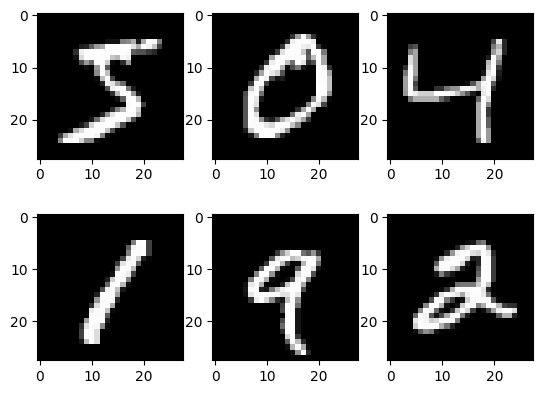

In [58]:
from numpy.random import shuffle
# MNIst dataset

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Hyper parameters
input_size = 784 # 28 * 28
hidden_size = 100
num_classes = 10
num_epoch = 2
batchSize = 100
learning_rate = 0.001

# MNIST data
train_dataset = datasets.MNIST(root = '/cnn_data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root = '/cnn_data', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=batchSize, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batchSize, shuffle=False)

for i, (X_Train, y_train) in enumerate(train_dataset):
  print(f'{i}')
  plt.subplot(2, 3, i+1)
  plt.imshow(X_Train[0], cmap='gray')
  if i == 5:
    break

class NeuralNet(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super().__init__()
    self.Linear1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.Linear2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.Linear1(x)
    out = self.relu(out)
    out = self.Linear2(out)
    return out

model = NeuralNet(input_size, hidden_size, num_classes)

# Loss function
Loss_fn = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loops
n_total_steps = len(train_loader)

for epoch in range(num_epoch):
  for i, (images, labels) in enumerate(train_loader):
    images = images.reshape(-1, 28*28)

    # Forward pass
    output = model(images)

    # Calculate loss
    Loss = Loss_fn(output, labels)

    # Backward pass
    optimizer.zero_grad()
    Loss.backward()
    optimizer.step()

    if (i+1)%100 == 0:
      print(f'epoch = {epoch+1}/{num_epoch}, step = {i+1}/{n_total_steps}: Loss = {Loss.item():.4f}')


with torch.no_grad():
  n_correct = 0
  n_samples = 0
  for images, labels in test_loader:
    images = images.reshape(-1, 28*28)
    outputs = model(images)

    _, predictions = torch.max(outputs, 1)
    n_samples += labels.shape[0]
    n_correct = (predictions == labels).sum().item()

acc = 100 * n_correct/n_samples
print(f'accuracy = {acc} %')


In [4]:
# Transfer Learning

# Model used for a first task is used for another task

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

model = models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad = False

num_input_features = model.fc.in_features

model.fc = nn.Linear(num_input_features, 2)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.001)

step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
pip install tensorboard

In [7]:
tensorboard --logdir=runs

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (3224537314.py, line 1)